In [19]:
import os

os.chdir("/workspaces/F1")

print("Working directory:", os.getcwd())


Working directory: /workspaces/F1


In [20]:
!pip install -r requirements.txt

In [21]:
!ls results

monza_telemetry.csv		 telemetry_conservative_soc6.csv
strategy_results.csv		 telemetry_conservative_soc8.csv
telemetry_aggressive_soc4.csv	 telemetry_lookahead_soc4.csv
telemetry_aggressive_soc6.csv	 telemetry_lookahead_soc6.csv
telemetry_aggressive_soc8.csv	 telemetry_lookahead_soc8.csv
telemetry_conservative_soc4.csv


In [22]:
# Generate strategy results (creates results/strategy_results.csv and telemetry files)
!python -m experiments.run_experiment

conservative     SOC=0.4  lap=81.72s  deployed=2.83MJ  soc_end=0.596
conservative     SOC=0.6  lap=81.72s  deployed=3.83MJ  soc_end=0.597
conservative     SOC=0.8  lap=81.72s  deployed=4.84MJ  soc_end=0.595
aggressive       SOC=0.4  lap=81.72s  deployed=4.00MJ  soc_end=0.363
aggressive       SOC=0.6  lap=81.72s  deployed=4.00MJ  soc_end=0.563
aggressive       SOC=0.8  lap=81.72s  deployed=4.00MJ  soc_end=0.763
lookahead        SOC=0.4  lap=81.72s  deployed=2.90MJ  soc_end=0.541
lookahead        SOC=0.6  lap=81.72s  deployed=2.90MJ  soc_end=0.541
lookahead        SOC=0.8  lap=81.72s  deployed=2.90MJ  soc_end=0.541

Saved to results/strategy_results.csv

--- Multi-lap test (conservative, SOC=0.6) ---
Lap 1: 81.72s  soc_end=0.597
Lap 2: 81.72s  soc_end=0.599
Lap 3: 81.72s  soc_end=0.596


In [23]:
import pandas as pd

df = pd.read_csv("results/monza_telemetry.csv")

df.head()

,time,power,soc,distance,speed
0,0.0,0.0,0.6,7.5,55.879630
1,0.2,0.0,0.6,22.5,56.527778
2,0.4,0.0,0.6,37.5,57.175926
3,0.6,0.0,0.6,52.5,57.824074
4,0.8,0.0,0.6,67.5,58.472222


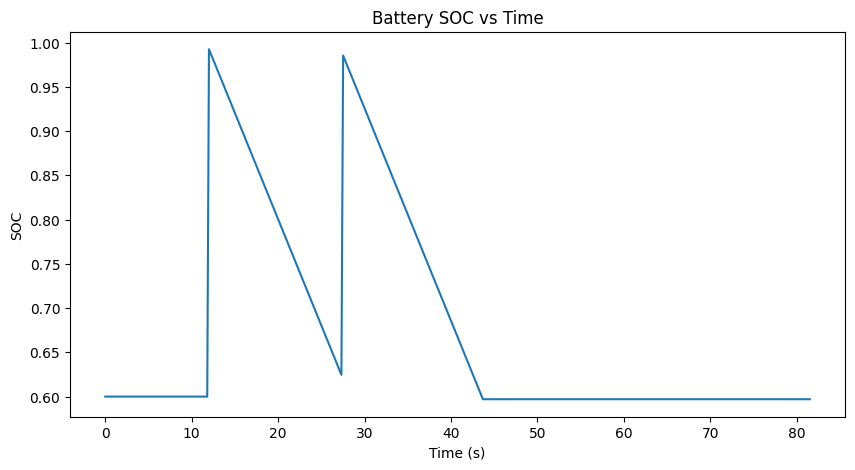

In [24]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,5))
plt.plot(df["time"], df["soc"])
plt.xlabel("Time (s)")
plt.ylabel("SOC")
plt.title("Battery SOC vs Time")
plt.show()


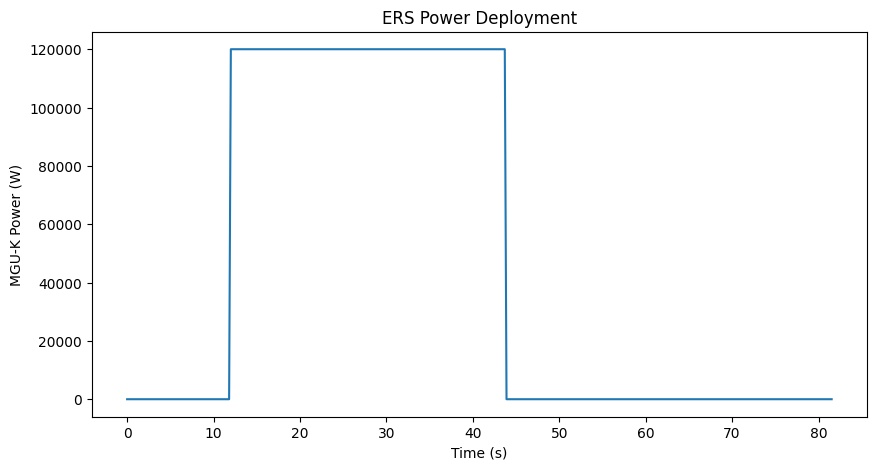

In [25]:
plt.figure(figsize=(10,5))
plt.plot(df["time"], df["power"])
plt.xlabel("Time (s)")
plt.ylabel("MGU-K Power (W)")
plt.title("ERS Power Deployment")
plt.show()

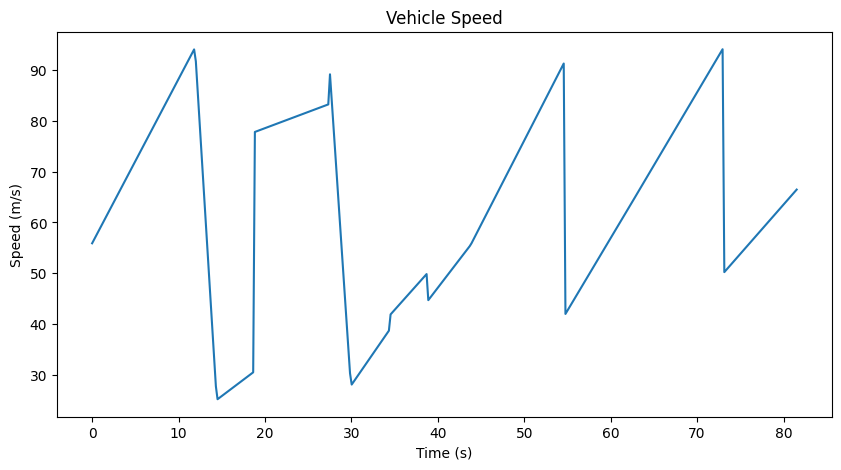

In [26]:
plt.figure(figsize=(10,5))
plt.plot(df["time"], df["speed"])
plt.xlabel("Time (s)")
plt.ylabel("Speed (m/s)")
plt.title("Vehicle Speed")
plt.show()

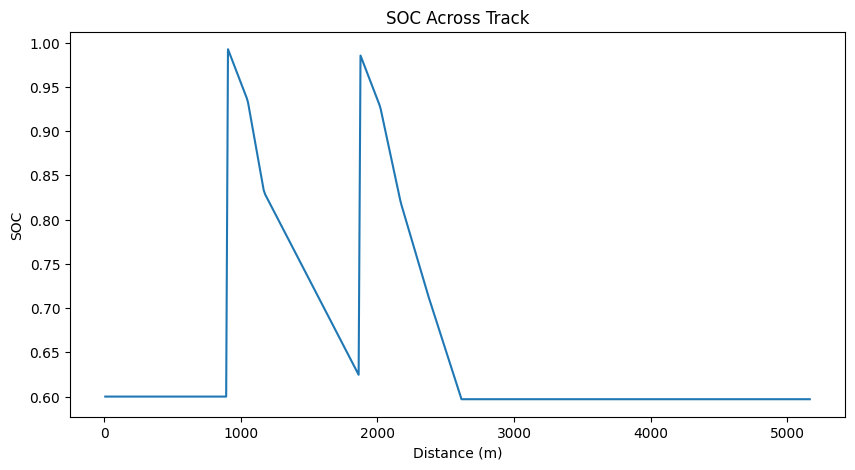

In [27]:
plt.figure(figsize=(10,5))
plt.plot(df["distance"], df["soc"])
plt.xlabel("Distance (m)")
plt.ylabel("SOC")
plt.title("SOC Across Track")
plt.show()

In [28]:
print("Telemetry summary")

print("Min SOC:", df["soc"].min())
print("Max SOC:", df["soc"].max())

print("Max power deployed:", df["power"].max())
print("Average power:", df["power"].mean())

Telemetry summary
Min SOC: 0.5970161969332435
Max SOC: 0.9925159262572052
Max power deployed: 120000.0
Average power: 47070.217917675545


In [38]:
# Load strategy results
import pandas as pd
import matplotlib.pyplot as plt

summary = pd.read_csv("results/strategy_results.csv")
strategies = ["conservative", "aggressive", "lookahead"]
socs = [0.4, 0.6, 0.8]
colors = {"conservative": "blue", "aggressive": "red", "lookahead": "green"}

FileNotFoundError: [Errno 2] No such file or directory: 'results/strategy_results.csv'

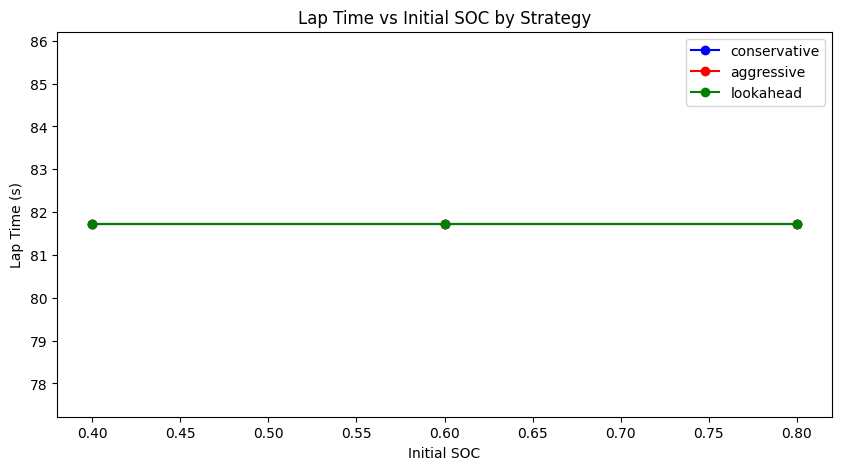

In [30]:
# 1. Lap time comparison
fig, ax = plt.subplots(figsize=(10, 5))
for s in strategies:
    d = summary[summary.strategy == s]
    ax.plot(d.initial_soc, d.lap_time, marker="o", label=s, color=colors[s])
ax.set_xlabel("Initial SOC"); ax.set_ylabel("Lap Time (s)")
ax.set_title("Lap Time vs Initial SOC by Strategy")
ax.legend(); plt.show()

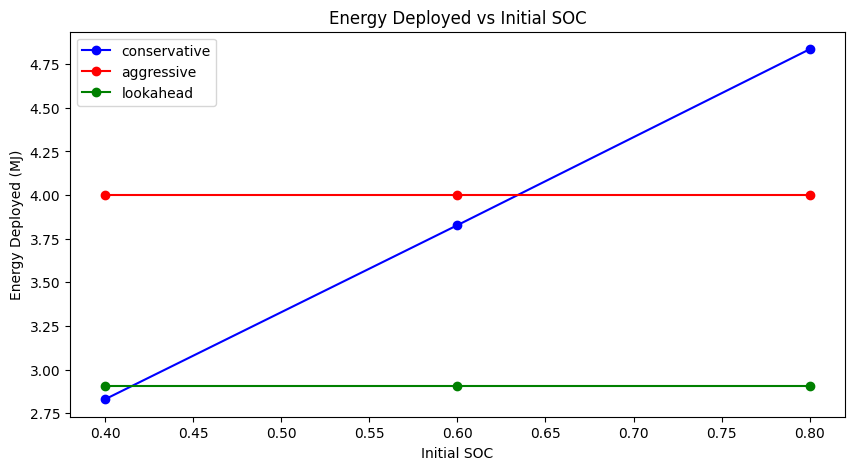

In [31]:
# 2. Energy deployed comparison
fig, ax = plt.subplots(figsize=(10, 5))
for s in strategies:
    d = summary[summary.strategy == s]
    ax.plot(d.initial_soc, d.energy_deployed_j / 1e6, marker="o", label=s, color=colors[s])
ax.set_xlabel("Initial SOC"); ax.set_ylabel("Energy Deployed (MJ)")
ax.set_title("Energy Deployed vs Initial SOC"); ax.legend(); plt.show()

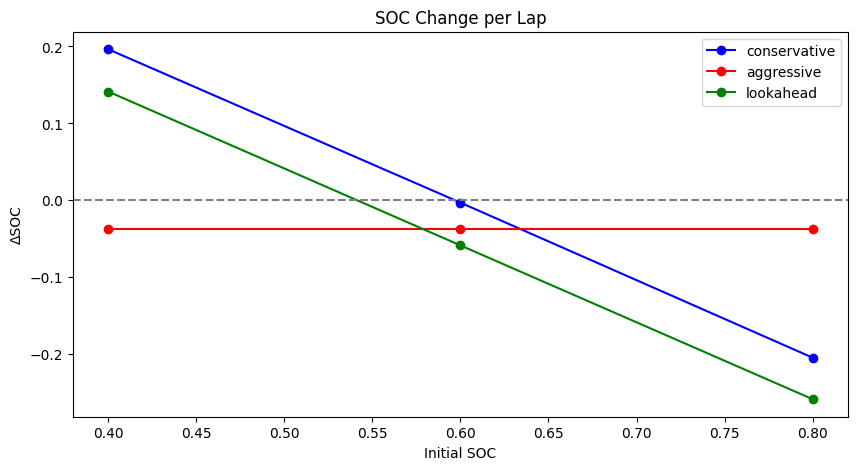

In [32]:
# 3. SOC delta (end - start)
fig, ax = plt.subplots(figsize=(10, 5))
for s in strategies:
    d = summary[summary.strategy == s]
    ax.plot(d.initial_soc, d.soc_end - d.initial_soc, marker="o", label=s, color=colors[s])
ax.axhline(0, linestyle="--", color="gray")
ax.set_xlabel("Initial SOC"); ax.set_ylabel("ΔSOC")
ax.set_title("SOC Change per Lap"); ax.legend(); plt.show()

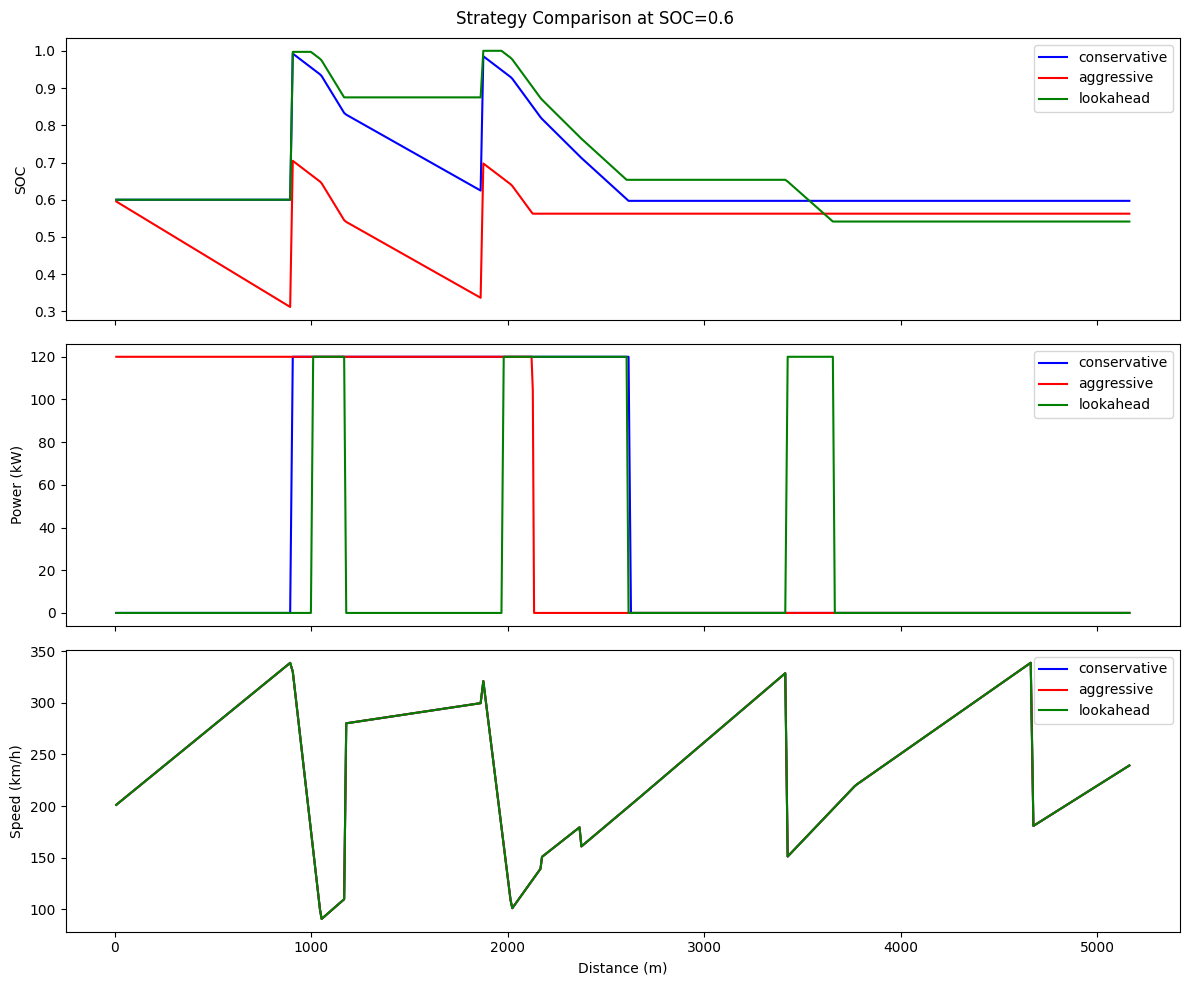

In [33]:
# 4. Per-strategy telemetry overlay (SOC=0.6)
fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)
for s in strategies:
    tel = pd.read_csv(f"results/telemetry_{s}_soc6.csv")
    axes[0].plot(tel.distance, tel.soc, label=s, color=colors[s])
    axes[1].plot(tel.distance, tel.power / 1000, label=s, color=colors[s])
    axes[2].plot(tel.distance, tel.speed * 3.6, label=s, color=colors[s])
for ax, ylabel in zip(axes, ["SOC", "Power (kW)", "Speed (km/h)"]):
    ax.set_ylabel(ylabel); ax.legend()
axes[2].set_xlabel("Distance (m)")
fig.suptitle("Strategy Comparison at SOC=0.6"); plt.tight_layout(); plt.show()

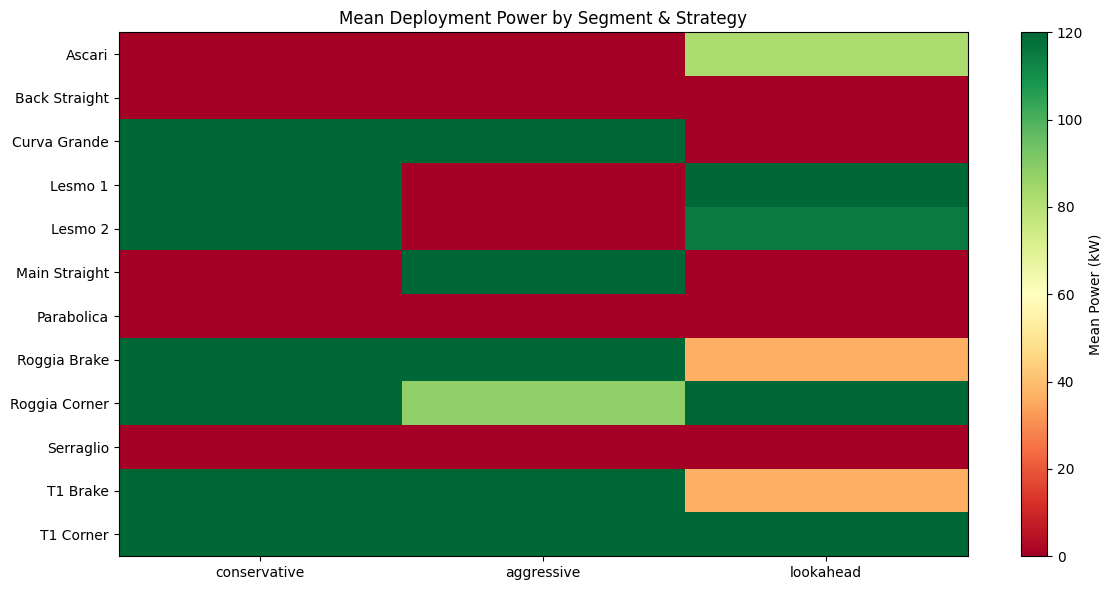

In [34]:
# 5. Segment-level mean power heatmap
import numpy as np
seg_data = {}
for s in strategies:
    tel = pd.read_csv(f"results/telemetry_{s}_soc6.csv")
    seg_data[s] = tel.groupby("segment_name")["power"].mean() / 1000

seg_df = pd.DataFrame(seg_data)
fig, ax = plt.subplots(figsize=(12, 6))
im = ax.imshow(seg_df.values, aspect="auto", cmap="RdYlGn")
ax.set_xticks(range(len(strategies))); ax.set_xticklabels(strategies)
ax.set_yticks(range(len(seg_df))); ax.set_yticklabels(seg_df.index)
plt.colorbar(im, ax=ax, label="Mean Power (kW)")
ax.set_title("Mean Deployment Power by Segment & Strategy"); plt.tight_layout(); plt.show()

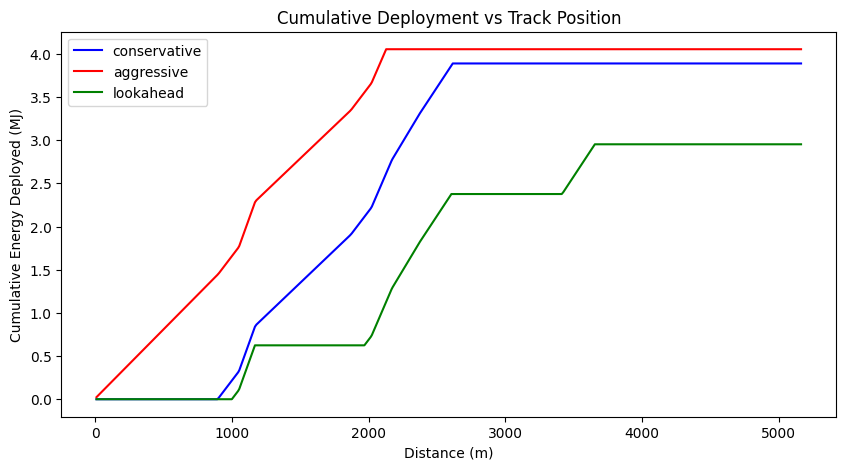

In [35]:
# 6. Cumulative energy deployed
fig, ax = plt.subplots(figsize=(10, 5))
for s in strategies:
    tel = pd.read_csv(f"results/telemetry_{s}_soc6.csv")
    ax.plot(tel.distance, tel.cumulative_energy_deployed_j / 1e6, label=s, color=colors[s])
ax.set_xlabel("Distance (m)"); ax.set_ylabel("Cumulative Energy Deployed (MJ)")
ax.set_title("Cumulative Deployment vs Track Position"); ax.legend(); plt.show()